In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Email_experiments.input.plot_styles import family_colors, set_plot_style, model_order, HALF_WIDTH
import seaborn as sns

In [2]:
set_plot_style()

In [3]:
# loading summary scores
summary_sharedtask = pd.read_csv("Shared_task_experiments/results/summary_sharedtask.csv")
summary_email_choice = pd.read_csv("Email_experiments/results/summary_choice.csv")
summary_email_yesno = pd.read_csv("Email_experiments/results/summary_yesno.csv")

In [4]:
summary_scores = pd.concat([summary_sharedtask, summary_email_yesno, summary_email_choice], ignore_index=True)

### Comparison Bystander Effect - Benchmarks

In [5]:
mmlu_scores = {'ministral14': np.float64(0.693),
 'ministral8': np.float64(0.642),
 'qwen8': np.float64(0.743),
 'qwen14': np.float64(0.774),
 'gemma12': np.float64(0.595),
 'gemma27': np.float64(0.669),
 'llama8': np.float64(0.476)}

In [6]:
gdpval_scores = {'ministral14': np.float64(658),
 'ministral8': np.float64(645),
 'qwen8': np.float64(479),
 'qwen14': np.float64(477),
 'gemma12': np.float64(300),
 'gemma27': np.float64(297),
 'llama8': np.float64(287)}

In [7]:
overall_effect = {}

for model in mmlu_scores:

    overall_effect[model] = summary_scores[model].mean()

In [8]:
overall_effect

{'ministral14': np.float64(0.22829157398512917),
 'ministral8': np.float64(0.2078777200172607),
 'qwen8': np.float64(0.2343189696739492),
 'qwen14': np.float64(0.1439120611508145),
 'gemma12': np.float64(0.4721041228514167),
 'gemma27': np.float64(0.6665015203489282),
 'llama8': np.float64(0.39357732873293316)}

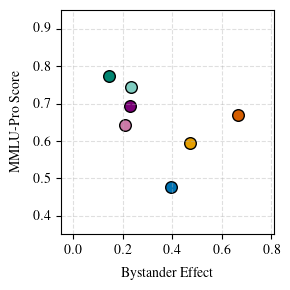

In [10]:
plt.figure(figsize=(HALF_WIDTH, HALF_WIDTH))

for model in overall_effect:
    plt.scatter(
        overall_effect[model],
        mmlu_scores[model],
        s=70,
        color=family_colors.get(model, "gray"),
        edgecolor="black",
        linewidth=1
    )
    
plt.xlabel("Bystander Effect", fontsize=10,  labelpad = 8)
plt.ylabel("MMLU-Pro Score", fontsize=10, labelpad = 8)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0.35, 0.95)
plt.xlim(-0.05, 0.81)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("plots_comparison/mmlu_score.pdf", bbox_inches='tight')
plt.show()

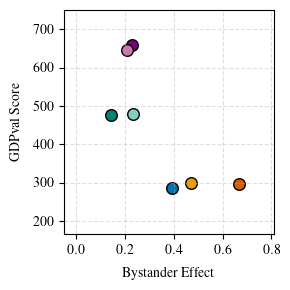

In [11]:
plt.figure(figsize=(HALF_WIDTH, HALF_WIDTH))

for model in overall_effect:
    plt.scatter(
        overall_effect[model],
        gdpval_scores[model],
        s=70,
        color=family_colors.get(model, "gray"),
        edgecolor="black",
        linewidth=1
    )
    
plt.xlabel("Bystander Effect", fontsize=10,  labelpad = 8)
plt.ylabel("GDPval Score", fontsize=10, labelpad = 8)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(165, 750)
plt.xlim(-0.05, 0.81)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("plots_comparison/gdpval_score.pdf", bbox_inches='tight')
plt.show()

### Calculating separate summary scores

In [12]:
benchmark_sharedtask = {'gemma12': np.float64(0.84746913119295),
                         'gemma27': np.float64(0.9997220504715445),
                         'qwen8': np.float64(0.9523274757011443),
                         'qwen14': np.float64(0.9374464514306281),
                         'ministral8': np.float64(0.9488542949912879),
                         'ministral14': np.float64(0.8051448779356021),
                         'llama8': np.float64(0.5139023619053205)}

In [13]:
benchmark_email = {'ministral14': np.float64(0.9465600535057487),
                     'ministral8': np.float64(0.9515216955090123),
                     'qwen8': np.float64(0.9885595038116892),
                     'qwen14': np.float64(0.9995514237293994),
                     'gemma12': np.float64(0.9982517667045051),
                     'gemma27': np.float64(0.9990156282540127),
                     'llama8': np.float64(0.8569752749312783)}

In [14]:
email_effect = {}

for model in benchmark_email:


    choice_values = np.array(summary_email_choice[model])
    yes_no_values = np.array(summary_email_yesno[model])
    all_values = np.concatenate((choice_values, yes_no_values))

    mean_email = np.mean(all_values)
    print(f"mean {model}:", mean_email)
    std_email = np.std(all_values)
    print(f"std {model}:", std_email)

    email_effect[model] = mean_email

mean ministral14: 0.33156362066348993
std ministral14: 0.09941219378658044
mean ministral8: 0.1482052142812601
std ministral8: 0.2440268003324013
mean qwen8: 0.29751985840810774
std qwen8: 0.1829767025191614
mean qwen14: 0.1391663879158714
std qwen14: 0.22397047014457858
mean gemma12: 0.4931505125467828
std gemma12: 0.25454252210859163
mean gemma27: 0.6240600620162567
std gemma27: 0.15998547271840483
mean llama8: 0.5889685760758023
std llama8: 0.0637068058500456


In [15]:
sharedtask_effect = {}

for model in benchmark_sharedtask:

    values_sharedtask = np.array(summary_sharedtask[model])

    mean_sharedtask = np.mean(values_sharedtask)
    std_sharedtask = np.std(values_sharedtask)

    sharedtask_effect[model] = mean_sharedtask

    print(f"mean {model}:", mean_sharedtask)
    print(f"std {model}:", std_sharedtask)

mean gemma12: 0.4510577331560505
std gemma12: 0.32343469252002044
mean gemma27: 0.7089429786815997
std gemma27: 0.24320748046538032
mean qwen8: 0.1711180809397906
std qwen8: 0.1718000457083408
mean qwen14: 0.14865773438575758
std qwen14: 0.14980094643175643
mean ministral8: 0.2675502257532613
std ministral8: 0.1643043968906585
mean ministral14: 0.12501952730676835
std ministral14: 0.054905687211553256
mean llama8: 0.19818608139006397
std llama8: 0.14440965698024524


### Relationship between email and shared task bystander effect

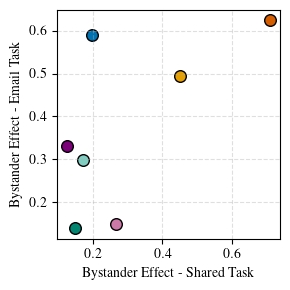

In [18]:
plt.figure(figsize=(HALF_WIDTH, HALF_WIDTH))

for model in sharedtask_effect:
    plt.scatter(
        sharedtask_effect[model],
        email_effect[model],
        s=70,
        color=family_colors.get(model, "gray"),
        edgecolor="black",
        linewidth=1
    )
    
plt.xlabel("Bystander Effect - Shared Task", fontsize=10,  labelpad = 5)
plt.ylabel("Bystander Effect - Email Task", fontsize=10, labelpad = 5)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

#plt.ylim(0.25, 1.0)
#plt.xlim(-0.05, 0.8)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

#plt.savefig("plots/benchmark/benchmark_comparisons_shared_task.pdf", bbox_inches='tight')
plt.show()

### Investigating relationship with empathy

In [19]:
# read in empathy scores
df_empathy = pd.read_csv("Empathy_analysis/empathy_results/empathy_scores.csv")

In [20]:
empathy_scores_overall = {}
empathy_scores_affective = {}
empathy_scores_cognitive = {}

for model in overall_effect:

    empathy_scores_overall[model] = df_empathy.loc[0, model]
    empathy_scores_affective[model] = df_empathy.loc[1, model]
    empathy_scores_cognitive[model] = df_empathy.loc[2, model]

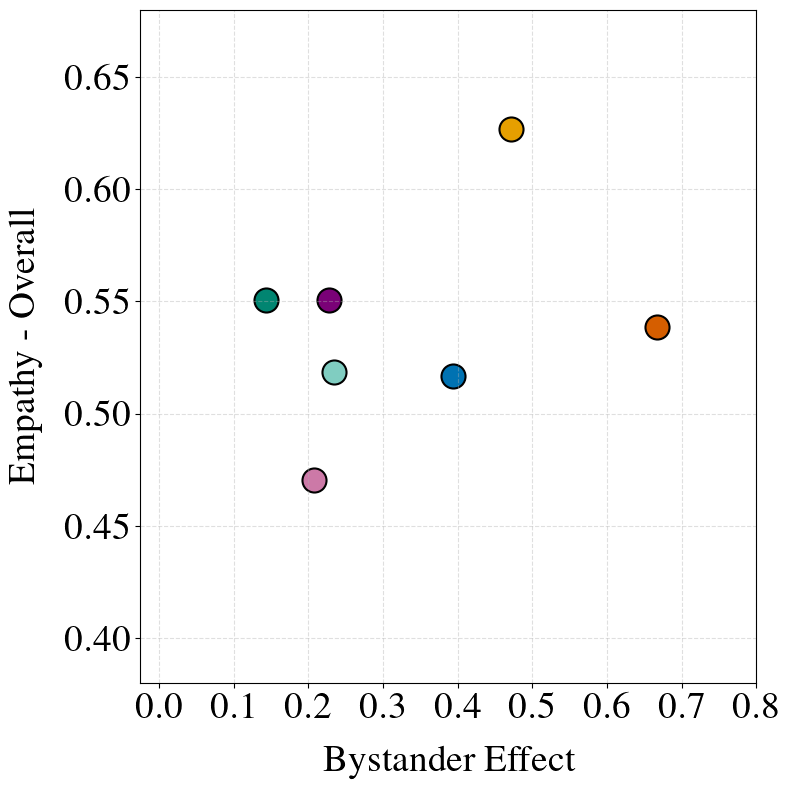

In [21]:
plt.figure(figsize=(8, 8))

for model in overall_effect:
    plt.scatter(
        overall_effect[model],
        empathy_scores_overall[model],
        s=300,
        color=family_colors.get(model, "gray"),
        edgecolor="black",
        linewidth=1.5
    )
    
plt.xlabel("Bystander Effect", fontsize=27,  labelpad = 15)
plt.ylabel("Empathy - Overall", fontsize=27, labelpad = 15)
plt.xticks(fontsize=27)
plt.yticks(fontsize=27)

plt.ylim(0.38, 0.68)
plt.xlim(-0.025, 0.8)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

#plt.savefig("plots/benchmark/benchmark_comparisons_shared_task.pdf", bbox_inches='tight')
plt.show()

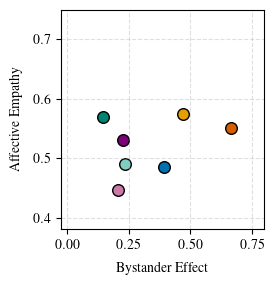

In [22]:
plt.figure(figsize=(HALF_WIDTH, HALF_WIDTH))

for model in overall_effect:
    plt.scatter(
        overall_effect[model],
        empathy_scores_affective[model],
        s=70,
        color=family_colors.get(model, "gray"),
        edgecolor="black",
        linewidth=1
    )
    
plt.xlabel("Bystander Effect", fontsize=10,  labelpad = 8)
plt.ylabel("Affective Empathy", fontsize=10, labelpad = 8)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0.38, 0.75)
plt.xlim(-0.025, 0.8)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("plots_comparison/affective_empathy.pdf", bbox_inches='tight')
plt.show()

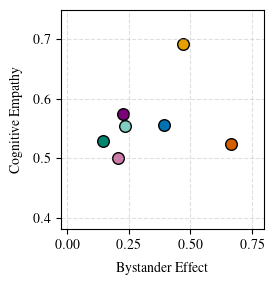

In [23]:
plt.figure(figsize=(HALF_WIDTH, HALF_WIDTH))

for model in overall_effect:
    plt.scatter(
        overall_effect[model],
        empathy_scores_cognitive[model],
        s=70,
        color=family_colors.get(model, "gray"),
        edgecolor="black",
        linewidth=1
    )
    
plt.xlabel("Bystander Effect", fontsize=10,  labelpad = 8)
plt.ylabel("Cognitive Empathy", fontsize=10, labelpad = 8)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.ylim(0.38, 0.75)
plt.xlim(-0.025, 0.8)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()

plt.savefig("plots_comparison/cognitive_empathy.pdf", bbox_inches='tight')
plt.show()

### All correlations 

In [24]:
df_all = pd.DataFrame([overall_effect, sharedtask_effect, email_effect, mmlu_scores,gdpval_scores, empathy_scores_overall, 
          empathy_scores_affective, empathy_scores_cognitive]).transpose()
df_all.columns = ["Bystander_overall", "Bystander_sharedtask", "Bystander_email", "MMLU-Pro", "GDPval",
                  "Empathy_overall", "Empathy_affective", "Empathy_cognitive"]

In [25]:
corr_matrix = df_all.corr()
corr_matrix

,Bystander_overall,Bystander_sharedtask,Bystander_email,MMLU-Pro,GDPval,Empathy_overall,Empathy_affective,Empathy_cognitive
Bystander_overall,1.000000,0.908491,0.894264,-0.434446,-0.759112,0.337173,0.324507,0.264579
Bystander_sharedtask,0.908491,1.000000,0.625402,-0.162786,-0.580509,0.269220,0.344008,0.131361
Bystander_email,0.894264,0.625402,1.000000,-0.636860,-0.795725,0.341252,0.237510,0.353340
MMLU-Pro,-0.434446,-0.162786,-0.636860,1.000000,0.491349,-0.012336,0.276813,-0.281345
GDPval,-0.759112,-0.580509,-0.795725,0.491349,1.000000,-0.450026,-0.401575,-0.382819
Empathy_overall,0.337173,0.269220,0.341252,-0.012336,-0.450026,1.000000,0.862175,0.879044
Empathy_affective,0.324507,0.344008,0.237510,0.276813,-0.401575,0.862175,1.000000,0.516367
Empathy_cognitive,0.264579,0.131361,0.353340,-0.281345,-0.382819,0.879044,0.516367,1.000000


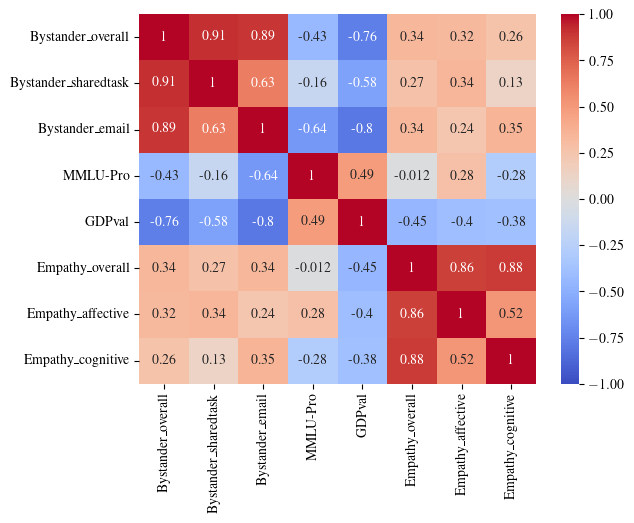

In [26]:
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [27]:
df_reduced = df_all.drop("gemma12")
df_reduced.corr()

,Bystander_overall,Bystander_sharedtask,Bystander_email,MMLU-Pro,GDPval,Empathy_overall,Empathy_affective,Empathy_cognitive
Bystander_overall,1.000000,0.897790,0.886432,-0.380547,-0.725508,0.131576,0.201779,-0.094083
Bystander_sharedtask,0.897790,1.000000,0.591976,-0.083086,-0.519610,0.013270,0.227166,-0.443985
Bystander_email,0.886432,0.591976,1.000000,-0.609065,-0.781567,0.226832,0.130508,0.294435
MMLU-Pro,-0.380547,-0.083086,-0.609065,1.000000,0.433438,0.371249,0.484004,-0.086199
GDPval,-0.725508,-0.519610,-0.781567,0.433438,1.000000,-0.221910,-0.255281,-0.019962
Empathy_overall,0.131576,0.013270,0.226832,0.371249,-0.221910,1.000000,0.920700,0.572487
Empathy_affective,0.201779,0.227166,0.130508,0.484004,-0.255281,0.920700,1.000000,0.207102
Empathy_cognitive,-0.094083,-0.443985,0.294435,-0.086199,-0.019962,0.572487,0.207102,1.000000


In [28]:
corr_matrix_rang = df_all.corr(method='spearman')

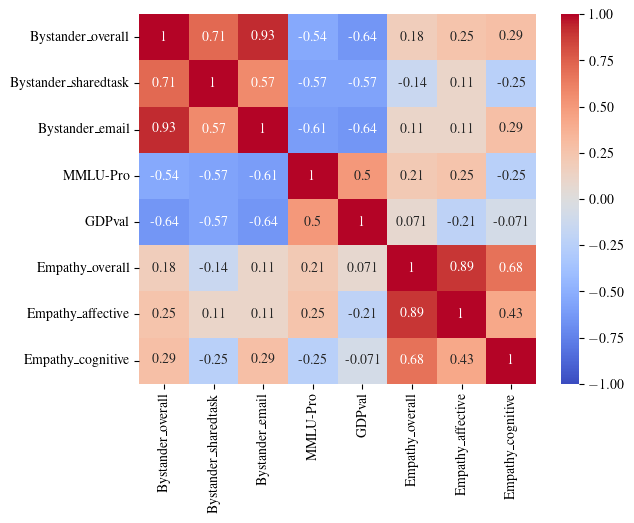

In [29]:
sns.heatmap(corr_matrix_rang, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [31]:
from scipy.stats import pearsonr

# Funktion, die Korrelation und p-Wert zurückgibt
def calculate_pvalues(df):
    df = df.dropna()._get_numeric_data()
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = pearsonr(df[r], df[c])
            pvalues[r][c] = round(tmp[1], 4)
    return pvalues

# Matrix berechnen
pvalues = calculate_pvalues(df_all)
print("Korrelationsmatrix (r):")
print(df_all.corr())
print("\nSignifikanzmatrix (p-Werte):")
print(pvalues)

Korrelationsmatrix (r):
                      Bystander_overall  Bystander_sharedtask  \
Bystander_overall              1.000000              0.908491   
Bystander_sharedtask           0.908491              1.000000   
Bystander_email                0.894264              0.625402   
MMLU-Pro                      -0.434446             -0.162786   
GDPval                        -0.759112             -0.580509   
Empathy_overall                0.337173              0.269220   
Empathy_affective              0.324507              0.344008   
Empathy_cognitive              0.264579              0.131361   

                      Bystander_email  MMLU-Pro    GDPval  Empathy_overall  \
Bystander_overall            0.894264 -0.434446 -0.759112         0.337173   
Bystander_sharedtask         0.625402 -0.162786 -0.580509         0.269220   
Bystander_email              1.000000 -0.636860 -0.795725         0.341252   
MMLU-Pro                    -0.636860  1.000000  0.491349        -0.012336   


/tmp/ipykernel_3835/4193701523.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvalues[r][c] = round(tmp[1], 4)


In [32]:
import statsmodels.api as sm

X = df_all[["MMLU-Pro", "GDPval"]]
y = df_all["Bystander_overall"]

# add intercept
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Bystander_overall   R-squared:                       0.581
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     2.776
Date:                Wed, 20 May 2026   Prob (F-statistic):              0.175
Time:                        08:01:33   Log-Likelihood:                 5.4488
No. Observations:                   7   AIC:                            -4.898
Df Residuals:                       4   BIC:                            -5.060
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8065      0.401      2.012      0.1

/home/jovyan/vllm_env/lib/python3.11/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
